# 02 — Fine-tuning PhoBERT cho Phân tích Cảm xúc

Notebook này thực hiện fine-tune **PhoBERT** (`vinai/phobert-base-v2`) cho bài toán
**Sentiment Classification** (Positive / Neutral / Negative) từ dữ liệu đánh giá sản phẩm tiếng Việt.

```
Load processed data → Dataset/DataLoader → Fine-tune PhoBERT (K-Fold)
    → Evaluate (Ensemble) → Save HuggingFace format → (Optional) Push to Hub
```

**Input:** `data/processed/*_labeled.csv` + `class_weights.json`  
**Output:** `models/phobert_sentiment/` (HuggingFace format, sẵn sàng deploy)


## 1. Khởi tạo môi trường

In [68]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
!pip install transformers datasets accelerate scikit-learn seaborn underthesea -q


In [70]:
import os, json, warnings, random, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix,
)
warnings.filterwarnings('ignore')

# ── Cấu hình đường dẫn ────────────────────────────────────────
BASE_PATH  = '/content/drive/MyDrive/sentiment_analyst/'
DATA_PATH  = BASE_PATH + 'data/processed/'
MODEL_PATH = BASE_PATH + 'models/phobert_sentiment/'
CKPT_PATH  = BASE_PATH + 'outputs/checkpoints/'
LOG_PATH   = BASE_PATH + 'outputs/logs/'
FIG_PATH   = BASE_PATH + 'outputs/figures/'

for p in [DATA_PATH, MODEL_PATH, CKPT_PATH, LOG_PATH, FIG_PATH]:
    os.makedirs(p, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super(NpEncoder, self).default(obj)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False


Device: cuda
GPU: Tesla T4


## 2. Siêu tham số

In [71]:
# ── Model ────────────────────────────────────────────────────
PHOBERT_NAME = 'vinai/phobert-base-v2'
NUM_LABELS   = 3
MAX_LEN      = 256

# ── Training ─────────────────────────────────────────────────
BATCH_SIZE       = 16      # Tránh OOM trên Colab T4
ACCUM_STEPS      = 8       # Effective BS = 128
NUM_WORKERS      = 0       # Colab không hỗ trợ multiprocess DataLoader ổn định
LEARNING_RATE    = 2e-5
NUM_EPOCHS       = 25
WARMUP_RATIO     = 0.1
MAX_GRAD_NORM    = 1.0
EARLY_STOP_PAT   = 7
DROPOUT_RATE     = 0.15

USE_AMP          = True
LLRD_FACTOR      = 0.95
USE_FOCAL_LOSS   = True
LABEL_SMOOTHING  = 0.1
K_FOLDS          = 5

# ── Label mapping ─────────────────────────────────────────────
LABEL_ENCODE = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
LABEL_DECODE = {v: k for k, v in LABEL_ENCODE.items()}
ID2LABEL     = LABEL_DECODE
LABEL2ID     = LABEL_ENCODE

print('Cấu hình:')
for k, v in {
    'Model': PHOBERT_NAME, 'MAX_LEN': MAX_LEN, 'BATCH_SIZE': BATCH_SIZE,
    'Effective BS': BATCH_SIZE * ACCUM_STEPS,
    'LR': LEARNING_RATE, 'EPOCHS': NUM_EPOCHS, 'EARLY_STOP': EARLY_STOP_PAT
}.items():
    print(f'  {k:15s}: {v}')


Cấu hình:
  Model          : vinai/phobert-base-v2
  MAX_LEN        : 256
  BATCH_SIZE     : 16
  Effective BS   : 128
  LR             : 2e-05
  EPOCHS         : 25
  EARLY_STOP     : 7


## 3. Tải dữ liệu

In [72]:
train_df = pd.read_csv(DATA_PATH + 'train_labeled.csv')
val_df   = pd.read_csv(DATA_PATH + 'val_labeled.csv')
test_df  = pd.read_csv(DATA_PATH + 'test_labeled.csv')

for df in [train_df, val_df, test_df]:
    if 'label' not in df.columns:
        df['label'] = df['sentiment'].map(LABEL_ENCODE)
    assert df['label'].notna().all(), 'Label chứa NaN — kiểm tra cột sentiment!'
    assert df['label'].isin([0, 1, 2]).all(), 'Label nằm ngoài range [0, 1, 2]!'

full_train_df = pd.concat([train_df, val_df]).reset_index(drop=True)
n_dup = full_train_df.duplicated(subset=['Review']).sum()
if n_dup > 0:
    print(f'⚠️  Cảnh báo: {n_dup} review bị trùng lặp trong full_train!')

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print(f'Các cột: {list(train_df.columns)}')
full_train_df[['Review', 'sentiment', 'label']].head(3)


⚠️  Cảnh báo: 30 review bị trùng lặp trong full_train!
Train: 7,760 | Val: 845 | Test: 2,146
Các cột: ['Review', 'sentiment', 'label']


,Review,sentiment,label
0,giày đẹp đi êm lắm,Positive,2
1,mình săn sale với giá khá rẻ chất_lượng ok shi...,Positive,2
2,hình_ảnh và video chỉ mang tính_chất minh_họa ...,Positive,2


In [73]:
# Tính toán class_weights trên toàn bộ full_train để phản ánh đúng phân phối
full_labels = full_train_df['label'].values
cw_values = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=full_labels
)
class_weights = torch.tensor(cw_values, dtype=torch.float).to(device)
print('Class weights (recomputed on full_train):', cw_values.tolist())

# Vẫn load json để xác thực LABEL_ENCODE
with open(DATA_PATH + 'class_weights.json', encoding='utf-8') as f:
    cw_data = json.load(f)
assert cw_data['label_encode'] == LABEL_ENCODE, \
    f"Label encode không khớp!\nJSON: {cw_data['label_encode']}\nCode: {LABEL_ENCODE}"


Class weights (recomputed on full_train): [3.289373088685015, 1.7521889635512116, 0.47052712160979876]


## 4. Dataset & DataLoader

In [74]:
tokenizer = AutoTokenizer.from_pretrained(PHOBERT_NAME)

class PhoBERTDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        # Trở lại Lazy Tokenization trong __getitem__ để giảm thiểu RAM memory leak trên Colab
        self.reviews   = df['Review'].astype(str).tolist()
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.reviews[idx],
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt',
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long),
        }

full_train_dataset = PhoBERTDataset(full_train_df, tokenizer, MAX_LEN)
test_dataset  = PhoBERTDataset(test_df,  tokenizer, MAX_LEN)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))

print(f'Full Train size: {len(full_train_dataset)} | Test: {len(test_dataset)}')

sample_reviews = full_train_df['Review'].sample(min(500, len(full_train_df)))
lengths = [len(tokenizer.encode(str(r))) for r in sample_reviews]
print(f'\nPhân tích độ dài Token (mẫu 500 reviews):')
print(f'  Mean={np.mean(lengths):.0f}, Median={np.median(lengths):.0f}')
print(f'  95th={np.percentile(lengths, 95):.0f}, Max={max(lengths)}')


Full Train size: 8605 | Test: 2146

Phân tích độ dài Token (mẫu 500 reviews):
  Mean=22, Median=19
  95th=48, Max=109


## 5. Các hàm hỗ trợ

In [75]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=-1)
        pt = probs.gather(1, targets.view(-1, 1)).squeeze(1)
        ce_loss = nn.functional.cross_entropy(
            logits, targets, weight=self.weight, label_smoothing=self.label_smoothing, reduction='none'
        )
        loss = ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean()

def get_llrd_params(model, base_lr, factor):
    params = []
    params.append({'params': model.classifier.parameters(), 'lr': base_lr})
    layers = model.roberta.encoder.layer
    for i, layer in enumerate(reversed(layers)):
        lr = base_lr * (factor ** (i + 1))
        params.append({'params': layer.parameters(), 'lr': lr})
    params.append({'params': model.roberta.embeddings.parameters(), 'lr': base_lr * (factor ** len(layers))})
    return params

def train_epoch(model, loader, optimizer, scheduler, criterion, device, scaler):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        with autocast(device_type=device.type, enabled=USE_AMP):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * ACCUM_STEPS
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            with autocast(device_type=device.type, enabled=USE_AMP):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss    = criterion(outputs.logits, labels)

            total_loss += loss.item()
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels


## 6. Huấn luyện với K-Fold Cross Validation


In [60]:
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(full_train_df, full_train_df['label'])):
    print(f'\n' + '='*50)
    print(f'🚀 FOLD {fold + 1}/{K_FOLDS}')
    print('='*50)

    train_sub = Subset(full_train_dataset, train_idx)
    val_sub   = Subset(full_train_dataset, val_idx)

    train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
    val_loader   = DataLoader(val_sub,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

    config = AutoConfig.from_pretrained(PHOBERT_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID)
    config.hidden_dropout_prob = DROPOUT_RATE
    config.attention_probs_dropout_prob = DROPOUT_RATE
    config.classifier_dropout = 0.3
    model = AutoModelForSequenceClassification.from_pretrained(PHOBERT_NAME, config=config).to(device)

    optimizer_grouped_parameters = get_llrd_params(model, LEARNING_RATE, LLRD_FACTOR)
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=LEARNING_RATE, weight_decay=0.01)

    total_steps  = len(train_loader) * NUM_EPOCHS // ACCUM_STEPS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    if USE_FOCAL_LOSS:
        criterion = FocalLoss(weight=class_weights, gamma=2.0, label_smoothing=LABEL_SMOOTHING)
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights)

    scaler = GradScaler('cuda', enabled=USE_AMP)

    best_val_f1 = 0.0
    early_stop_cnt = 0
    history = {'train_loss':[], 'train_f1':[], 'val_loss':[], 'val_f1':[], 'lr':[]}

    for epoch in range(1, NUM_EPOCHS + 1):
        current_lr = optimizer.param_groups[0]['lr']
        tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, optimizer, scheduler, criterion, device, scaler)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_f1'].append(tr_f1)
        history['val_loss'].append(vl_loss)
        history['val_f1'].append(vl_f1)
        history['lr'].append(current_lr)

        note = ''
        if vl_f1 > best_val_f1:
            best_val_f1 = vl_f1
            early_stop_cnt = 0
            note = '✅ best'
            model.save_pretrained(CKPT_PATH + f'best_model_fold_{fold+1}')
            tokenizer.save_pretrained(CKPT_PATH + f'best_model_fold_{fold+1}')
        else:
            early_stop_cnt += 1
            note = f'EStop {early_stop_cnt}/{EARLY_STOP_PAT}'

        print(f'Epoch {epoch:>2} | LR={current_lr:.2e} | TrL={tr_loss:.4f} TrF1={tr_f1:.4f} | VlL={vl_loss:.4f} VlF1={vl_f1:.4f} | {note}')

        if early_stop_cnt >= EARLY_STOP_PAT:
            print(f'⏹ Early stopping Fold {fold+1} tại epoch {epoch}.')
            break

    print(f'✅ Fold {fold+1} Best Val F1: {best_val_f1:.4f}')
    fold_results.append(best_val_f1)

    with open(LOG_PATH + f'training_history_fold_{fold+1}.json', 'w', encoding='utf-8') as fout:
        json.dump(history, fout, indent=2, cls=NpEncoder)

    del model, optimizer, scheduler, scaler
    gc.collect()
    torch.cuda.empty_cache()

print(f'\n🏆 K-FOLD AVERAGE BEST VAL F1: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}')



🚀 FOLD 1/5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch  1 | LR=0.00e+00 | TrL=0.5269 TrF1=0.3164 | VlL=0.4896 VlF1=0.5564 | ✅ best


...

Epoch  9 | LR=1.72e-05 | TrL=0.1390 TrF1=0.8430 | VlL=0.2545 VlF1=0.7661 | ✅ best


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 10 | LR=1.61e-05 | TrL=0.1330 TrF1=0.8485 | VlL=0.2566 VlF1=0.7726 | ✅ best
Epoch 11 | LR=1.50e-05 | TrL=0.1260 TrF1=0.8591 | VlL=0.2730 VlF1=0.7661 | EStop 1/7


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 12 | LR=1.37e-05 | TrL=0.1125 TrF1=0.8749 | VlL=0.3171 VlF1=0.7795 | ✅ best
Epoch 13 | LR=1.24e-05 | TrL=0.1042 TrF1=0.8831 | VlL=0.2787 VlF1=0.7715 | EStop 1/7
Epoch 14 | LR=1.10e-05 | TrL=0.0912 TrF1=0.8951 | VlL=0.2885 VlF1=0.7747 | EStop 2/7
Epoch 15 | LR=9.59e-06 | TrL=0.0896 TrF1=0.8990 | VlL=0.2924 VlF1=0.7717 | EStop 3/7
Epoch 16 | LR=8.20e-06 | TrL=0.0774 TrF1=0.9102 | VlL=0.3551 VlF1=0.7795 | EStop 4/7
Epoch 17 | LR=6.84e-06 | TrL=0.0788 TrF1=0.9118 | VlL=0.3168 VlF1=0.7704 | EStop 5/7
Epoch 18 | LR=5.55e-06 | TrL=0.0719 TrF1=0.9210 | VlL=0.3674 VlF1=0.7769 | EStop 6/7
Epoch 19 | LR=4.34e-06 | TrL=0.0722 TrF1=0.9215 | VlL=0.3428 VlF1=0.7739 | EStop 7/7
⏹ Early stopping Fold 5 tại epoch 19.
✅ Fold 5 Best Val F1: 0.7795

🏆 K-FOLD AVERAGE BEST VAL F1: 0.7931 ± 0.0120


## 7. Biểu đồ quá trình huấn luyện (Best Fold)

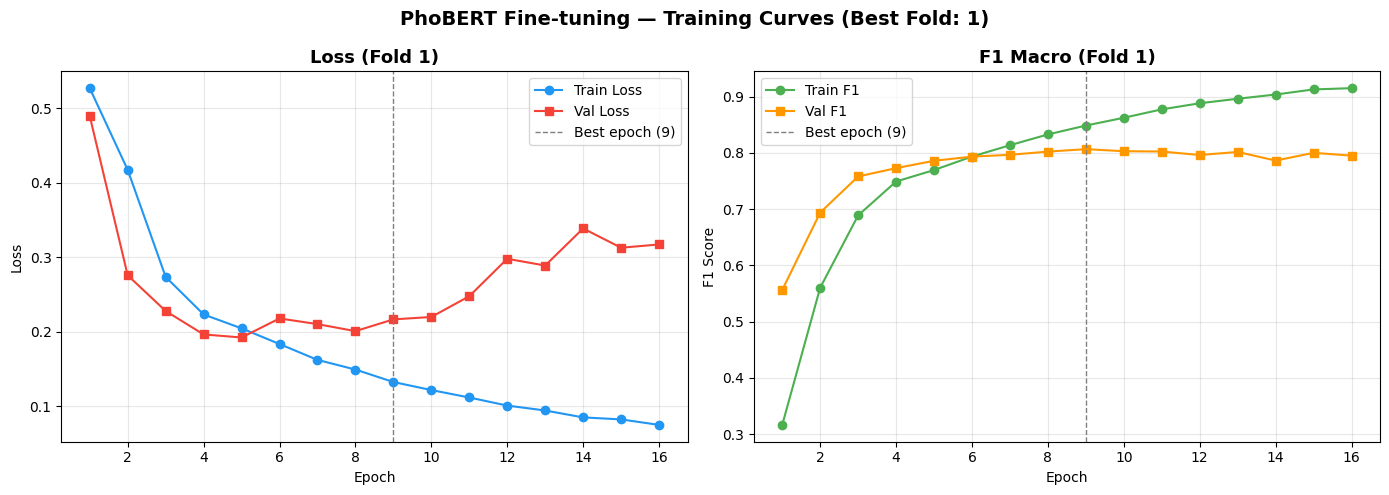

In [61]:
if 'fold_results' in globals():
    best_fold = np.argmax(fold_results) + 1
    with open(LOG_PATH + f'training_history_fold_{best_fold}.json', 'r', encoding='utf-8') as f:
        history = json.load(f)
    epochs_range = range(1, len(history['train_loss']) + 1)
    best_epoch = np.argmax(history['val_f1']) + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#2196F3')
    axes[0].plot(epochs_range, history['val_loss'],   's-', label='Val Loss',   color='#F44336')
    axes[0].axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
    axes[0].set_title(f'Loss (Fold {best_fold})', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history['train_f1'], 'o-', label='Train F1', color='#4CAF50')
    axes[1].plot(epochs_range, history['val_f1'],   's-', label='Val F1',   color='#FF9800')
    axes[1].axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
    axes[1].set_title(f'F1 Macro (Fold {best_fold})', fontweight='bold', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Score')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(f'PhoBERT Fine-tuning — Training Curves (Best Fold: {best_fold})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_PATH + 'training_curves.png', bbox_inches='tight', dpi=150)
    plt.show()


## 8. Đánh giá trên tập Test

In [62]:
print('Tiến hành Ensemble 5 models trên Test Set...')

test_labels = []
with torch.no_grad():
    for batch in test_loader:
        test_labels.extend(batch['label'].numpy())
test_labels = np.array(test_labels)

all_logits = []
successful_folds = []
EVAL_DONE = False

for fold in range(1, K_FOLDS + 1):
    ckpt_path = CKPT_PATH + f'best_model_fold_{fold}'
    if not os.path.exists(ckpt_path):
        print(f'⚠️  Warning: Checkpoint for fold {fold} not found. Skipping.')
        continue

    try:
        fold_model = AutoModelForSequenceClassification.from_pretrained(ckpt_path).to(device)
        fold_model.eval()

        fold_logits = []
        with torch.no_grad():
            for batch in test_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                with autocast(device_type=device.type, enabled=USE_AMP):
                    outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask)
                fold_logits.append(outputs.logits.cpu())

        all_logits.append(torch.cat(fold_logits, dim=0))
        successful_folds.append(fold)
        print(f'✅ Fold {fold} loaded successfully')

        del fold_model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f'❌ Error loading fold {fold}: {e}')
        continue

if not all_logits:
    print('❌ ERROR: Không có fold nào thành công!')
else:
    print(f'\n✅ Successfully loaded {len(successful_folds)} folds: {successful_folds}')

    all_probs = [torch.softmax(logits, dim=-1) for logits in all_logits]
    ensemble_probs = torch.stack(all_probs).mean(dim=0)
    test_preds = ensemble_probs.argmax(dim=-1).numpy()

    label_names = ['Negative', 'Neutral', 'Positive']
    print('\n=== KẾT QUẢ TRÊN TẬP TEST ===')
    print(f'Accuracy        : {accuracy_score(test_labels, test_preds):.4f}')
    print(f'F1 Macro        : {f1_score(test_labels, test_preds, average="macro", zero_division=0):.4f}')
    print(f'F1 Weighted     : {f1_score(test_labels, test_preds, average="weighted", zero_division=0):.4f}')
    print()
    print(classification_report(test_labels, test_preds, target_names=label_names, zero_division=0))


Tiến hành Ensemble 5 models trên Test Set...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Fold 1 loaded successfully


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Fold 2 loaded successfully


...

✅ Fold 3 loaded successfully


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Fold 4 loaded successfully


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Fold 5 loaded successfully

✅ Successfully loaded 5 folds: [1, 2, 3, 4, 5]

=== KẾT QUẢ TRÊN TẬP TEST ===
Accuracy        : 0.8756
F1 Macro        : 0.8226
F1 Weighted     : 0.8788

              precision    recall  f1-score   support

    Negative       0.86      0.78      0.82       231
     Neutral       0.66      0.78      0.71       416
    Positive       0.95      0.92      0.93      1499

    accuracy                           0.88      2146
   macro avg       0.82      0.83      0.82      2146
weighted avg       0.88      0.88      0.88      2146



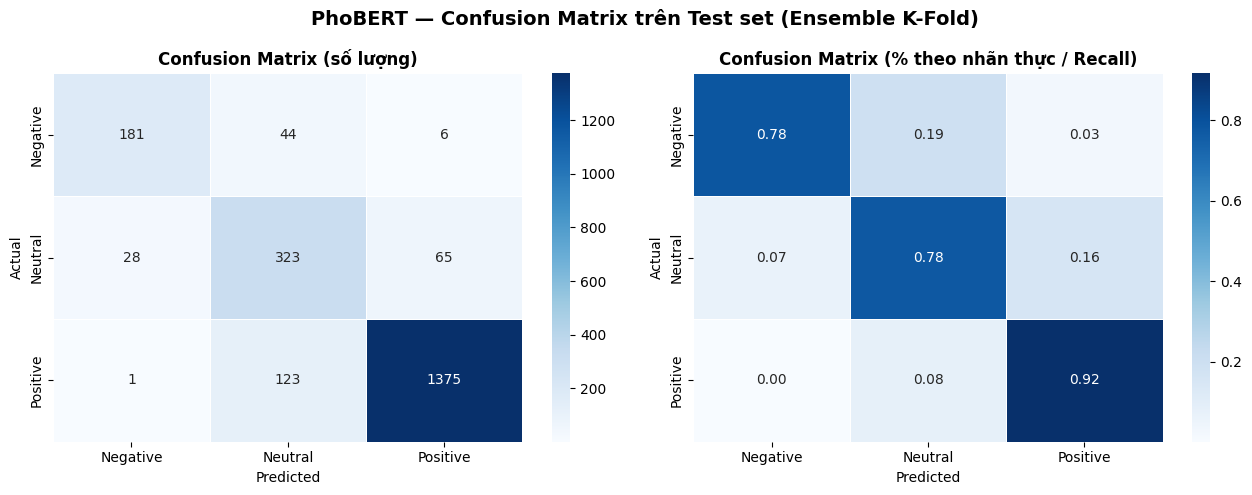

In [63]:
if 'all_logits' in globals() and 'test_preds' in globals():
    cm      = confusion_matrix(test_labels, test_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, data, fmt, title in [
        (axes[0], cm,      'd',    'Confusion Matrix (số lượng)'),
        (axes[1], cm_norm, '.2f', 'Confusion Matrix (% theo nhãn thực / Recall)'),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=label_names, yticklabels=label_names,
                    linewidths=0.5, ax=ax)
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.suptitle(f'PhoBERT — Confusion Matrix trên Test set (Ensemble K-Fold)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_PATH + 'confusion_matrix.png', bbox_inches='tight', dpi=150)
    plt.show()


In [64]:
if 'all_logits' in globals() and 'test_preds' in globals():
    report_dict = classification_report(test_labels, test_preds, target_names=label_names, output_dict=True, zero_division=0)
    test_results = {
        'accuracy'   : float(accuracy_score(test_labels, test_preds)),
        'f1_macro'   : float(f1_score(test_labels, test_preds, average='macro',    zero_division=0)),
        'f1_weighted': float(f1_score(test_labels, test_preds, average='weighted', zero_division=0)),
        'precision_macro': float(precision_score(test_labels, test_preds, average='macro', zero_division=0)),
        'recall_macro'   : float(recall_score(test_labels, test_preds, average='macro', zero_division=0)),
        'ensemble_used'  : True,
        'per_class'  : report_dict,
    }
    with open(LOG_PATH + 'test_results.json', 'w', encoding='utf-8') as f:
        json.dump(test_results, f, indent=2, ensure_ascii=False, cls=NpEncoder)
    print('✅ Đã lưu kết quả vào test_results.json')
    EVAL_DONE = True


✅ Đã lưu kết quả vào test_results.json


## 9. Lưu mô hình (Best Fold) để Deploy


In [65]:
if 'EVAL_DONE' in globals() and EVAL_DONE:
    # Note: Lưu fold có val_f1 cao nhất. Trên thực tế có thể chọn fold có test_f1 cao nhất nếu không ensemble.
    best_fold = np.argmax(fold_results) + 1

    model_card = f"""---
language: vi
tags:
  - sentiment-analysis
  - vietnamese
  - phobert
  - text-classification
datasets:
  - custom-shopee-reviews
metrics:
  - f1
  - accuracy
pipeline_tag: text-classification
---

# PhoBERT Vietnamese Sentiment Analysis

Mô hình phân tích cảm xúc tiếng Việt fine-tuned từ [vinai/phobert-base-v2](https://huggingface.co/vinai/phobert-base-v2)
trên tập dữ liệu đánh giá sản phẩm thương mại điện tử.

## Nhãn
| Label | ID | Mô tả |
|-------|----|-----------|
| Negative | 0 | Đánh giá tiêu cực |
| Neutral  | 1 | Đánh giá trung tính / hỗn hợp |
| Positive | 2 | Đánh giá tích cực |

## Tiền xử lý bắt buộc
Văn bản **phải được tách từ** bằng `underthesea.word_tokenize(text, format='text')`
trước khi đưa vào model.

## Kết quả
| Metric | Score |
|--------|-------|
| Accuracy | {test_results['accuracy']:.4f} |
| F1 Macro | {test_results['f1_macro']:.4f} |
| F1 Weighted | {test_results['f1_weighted']:.4f} |
"""
    torch.cuda.empty_cache()

    best_model_to_save = AutoModelForSequenceClassification.from_pretrained(CKPT_PATH + f'best_model_fold_{best_fold}')
    best_model_to_save.save_pretrained(MODEL_PATH)
    tokenizer.save_pretrained(MODEL_PATH)
    del best_model_to_save
    gc.collect()

    with open(MODEL_PATH + 'README.md', 'w', encoding='utf-8') as f:
        f.write(model_card)
    print('✅ Model đã lưu tại:', MODEL_PATH)
else:
    print('⚠️  Warning: Chưa có kết quả test_results hoặc fold_results. Bỏ qua bước tạo Model Card.')


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model đã lưu tại: /content/drive/MyDrive/sentiment_analyst/models/phobert_sentiment/


## 10. Demo Inference

In [66]:
from underthesea import word_tokenize
import unicodedata, re

TEENCODE = {
    'ko':'không','k':'không','kh':'không','khong':'không',
    'đc':'được','dc':'được',
    'cx':'cũng','nma':'nhưng mà','sp':'sản phẩm',
    'mn':'mọi người','mng':'mọi người',
    'vl':'rất','vkl':'rất',
    'oke':'ok','okie':'ok','oki':'ok','okela':'ok','okila':'ok',
    'ship':'giao hàng','ib':'nhắn_tin','rep':'phản_hồi','feedback':'đánh_giá',
}
EMOJI = {
    '❤️':'tích_cực','🧡':'tích_cực','💛':'tích_cực','💚':'tích_cực',
    '💙':'tích_cực','💜':'tích_cực','🤍':'tích_cực','❣️':'tích_cực',
    '💗':'tích_cực','💓':'tích_cực','😍':'tích_cực','🥰':'tích_cực',
    '😊':'tích_cực','😄':'tích_cực','😁':'tích_cực','🤩':'tích_cực',
    '😻':'tích_cực','🌟':'tích_cực','⭐':'tích_cực','👍':'tích_cực',
    '💪':'tích_cực','✅':'tích_cực','👌':'tích_cực',
    '😡':'tiêu_cực','😠':'tiêu_cực','🤬':'tiêu_cực','😤':'tiêu_cực',
    '👎':'tiêu_cực','❌':'tiêu_cực','😭':'tiêu_cực','😢':'tiêu_cực','🥲':'tiêu_cực',
}

# ⚠️ QUAN TRỌNG: Hàm này PHẢI giống hệt hàm preprocess() trong notebook 01.
# Nếu sửa một bên, phải sửa cả bên kia.
def preprocess(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'@\w+', '', text)
    for emo, val in EMOJI.items(): text = text.replace(emo, f' {val} ')
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    words = [TEENCODE.get(w, w) for w in text.split()]
    text  = ' '.join(words)
    text  = re.sub(r'!+', '!', text)
    text  = re.sub(r'\?+', '?', text)
    text  = re.sub(r'[^\w\s!?_]', ' ', text)
    text  = re.sub(r'\s+', ' ', text).strip()

    if not text:
        return ''

    try:
        text = word_tokenize(text, format='text')
    except TypeError:
        try:
            result = word_tokenize(text)
            text = ' '.join(result) if isinstance(result, list) else result
        except Exception:
            pass
    return text

try:
    best_fold_id = np.argmax(fold_results) + 1
except NameError:
    print('⚠️  Warning: Không tìm thấy fold_results, fallback dùng fold 1. Có thể đây không phải fold tốt nhất.')
    best_fold_id = 1

ckpt_path = CKPT_PATH + f'best_model_fold_{best_fold_id}'
if not os.path.exists(ckpt_path):
    print(f'❌ ERROR: Checkpoint không tồn tại tại {ckpt_path}')
else:
    inference_model = AutoModelForSequenceClassification.from_pretrained(ckpt_path).to(device)
    print(f'✅ Đã load inference_model từ fold {best_fold_id}.')

def predict(text, model, tokenizer, device, threshold=0.4):
    model.eval()
    processed = preprocess(text)
    if not processed:
        return {'label': 'Unknown', 'confidence': 0.0, 'probs': {ID2LABEL[i]: 0.0 for i in range(NUM_LABELS)}, 'preprocessed': ''}

    try:
        enc = tokenizer(processed, max_length=MAX_LEN, padding='max_length', truncation=True, return_tensors='pt')
        with torch.no_grad():
            outputs = model(input_ids=enc['input_ids'].to(device), attention_mask=enc['attention_mask'].to(device))
        probs      = torch.softmax(outputs.logits, dim=-1).cpu().squeeze()
        pred_id    = probs.argmax().item()
        confidence = probs[pred_id].item()

        if confidence < threshold:
            return {'label': 'Unknown', 'confidence': confidence, 'probs': {ID2LABEL[i]: round(p.item(), 4) for i, p in enumerate(probs)}, 'preprocessed': processed}
        return {'label': ID2LABEL[pred_id], 'confidence': confidence, 'probs': {ID2LABEL[i]: round(p.item(), 4) for i, p in enumerate(probs)}, 'preprocessed': processed}
    except Exception as e:
        return {'label': 'Error', 'confidence': 0.0, 'probs': {}, 'preprocessed': processed, 'error': str(e)}

test_cases = [
    'Giao hàng nhanh 👍, sản phẩm đẹp lắm mọi người nên mua!',
    'Chất lượng bình thường, giá hơi cao nhưng ship nhanh',
    'Hàng giả, chất lượng kém, giao hàng chậm. Không mua lại!',
    'shop nhiệt tình ko ngờ đẹp vl luôn 😍😍',
]
print('\n=== DEMO INFERENCE ===')
if 'inference_model' in globals():
    for text in test_cases:
        result = predict(text, inference_model, tokenizer, device)
        print(f'Input      : {text}')
        print(f'Preprocessed: {result["preprocessed"]}')
        print(f'Kết quả    : {result["label"]} (confidence: {result["confidence"]:.4f})')
        print(f'Xác suất   : {result["probs"]}')
        if 'error' in result:
            print(f'⚠️  Error: {result["error"]}')
        print()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Đã load inference_model từ fold 1.

=== DEMO INFERENCE ===
Input      : Giao hàng nhanh 👍, sản phẩm đẹp lắm mọi người nên mua!
Preprocessed: giao hàng nhanh tích_cực sản_phẩm đẹp lắm mọi người nên mua !
Kết quả    : Positive (confidence: 0.9440)
Xác suất   : {'Negative': 0.0171, 'Neutral': 0.0389, 'Positive': 0.944}

Input      : Chất lượng bình thường, giá hơi cao nhưng ship nhanh
Preprocessed: chất_lượng bình_thường giá hơi cao nhưng giao hàng nhanh
Kết quả    : Neutral (confidence: 0.6643)
Xác suất   : {'Negative': 0.0392, 'Neutral': 0.6643, 'Positive': 0.2965}

Input      : Hàng giả, chất lượng kém, giao hàng chậm. Không mua lại!
Preprocessed: hàng giả chất_lượng kém giao hàng chậm không mua lại !
Kết quả    : Negative (confidence: 0.8237)
Xác suất   : {'Negative': 0.8237, 'Neutral': 0.1526, 'Positive': 0.0237}

Input      : shop nhiệt tình ko ngờ đẹp vl luôn 😍😍
Preprocessed: shop nhiệt_tình không ngờ đẹp rất luôn tích_cực tích_cực
Kết quả    : Positive (confidence: 0.9412)
Xác s

In [67]:
# ============================================================
# EXPORT MODEL — Lưu toàn bộ để deploy HuggingFace Space
# ============================================================
import os, json, zipfile, gc, shutil
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# ── Chọn fold tốt nhất ──────────────────────────────────────
best_fold = int(np.argmax(fold_results) + 1)
print(f'Best fold: {best_fold} (Val F1 = {fold_results[best_fold-1]:.4f})')

EXPORT_PATH = BASE_PATH + 'models/phobert_sentiment_final/'
ZIP_PATH    = BASE_PATH + 'phobert_sentiment_export.zip'

# ✅ Xóa folder cũ nếu tồn tại để tránh lẫn file từ run trước
if os.path.exists(EXPORT_PATH):
    shutil.rmtree(EXPORT_PATH)
    print(f'🗑️  Đã xóa folder cũ: {EXPORT_PATH}')
os.makedirs(EXPORT_PATH, exist_ok=True)

# ── 1. Load best fold checkpoint ────────────────────────────
print('\n[1/4] Loading best checkpoint...')
model = AutoModelForSequenceClassification.from_pretrained(
    CKPT_PATH + f'best_model_fold_{best_fold}'
).to('cpu')
tokenizer = AutoTokenizer.from_pretrained(
    CKPT_PATH + f'best_model_fold_{best_fold}'
)

# ── 2. Lưu HuggingFace format ───────────────────────────────
print('[2/4] Saving model + tokenizer...')
model.save_pretrained(EXPORT_PATH, safe_serialization=True)
tokenizer.save_pretrained(EXPORT_PATH)

assert os.path.exists(EXPORT_PATH + 'model.safetensors'), \
    '❌ model.safetensors không tồn tại — save_pretrained thất bại!'
assert os.path.exists(EXPORT_PATH + 'tokenizer_config.json'), \
    '❌ tokenizer_config.json không tồn tại — tokenizer save thất bại!'
print('   ✅ Verified: model + tokenizer files OK')

del model
gc.collect()

# ── 3. Lưu metadata ─────────────────────────────────────────
print('[3/4] Saving metadata...')

try:
    _acc = round(float(test_results['accuracy']),    4)
    _f1m = round(float(test_results['f1_macro']),    4)
    _f1w = round(float(test_results['f1_weighted']), 4)
except NameError:
    _acc = _f1m = _f1w = None
    print('   ⚠️  test_results chưa có — chạy Section 8 trước nếu muốn lưu test metrics')

meta = {
    'base_model'      : PHOBERT_NAME,
    'num_labels'      : NUM_LABELS,
    'label2id'        : LABEL2ID,
    'id2label'        : {str(k): v for k, v in ID2LABEL.items()},
    'max_len'         : MAX_LEN,
    'best_fold'       : best_fold,
    'fold_val_f1'     : [round(float(f), 4) for f in fold_results],
    'best_val_f1'     : round(float(fold_results[best_fold - 1]), 4),
    'test_accuracy'   : _acc,
    'test_f1_macro'   : _f1m,
    'test_f1_weighted': _f1w,
}
with open(EXPORT_PATH + 'training_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print('   ✅ training_meta.json saved')

# ── 4. Zip toàn bộ ──────────────────────────────────────────
print('[4/4] Zipping...')
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for dirpath, dirnames, filenames in os.walk(EXPORT_PATH):
        for fname in filenames:
            abs_path = os.path.join(dirpath, fname)
            arc_name = os.path.relpath(abs_path, EXPORT_PATH)
            zf.write(abs_path, arcname=arc_name)

size_mb = os.path.getsize(ZIP_PATH) / 1024 / 1024
print(f'\n✅ Export xong!')
print(f'   Folder : {EXPORT_PATH}')
print(f'   ZIP    : {ZIP_PATH} ({size_mb:.1f} MB)')
print(f'\nFiles trong ZIP:')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    for info in zf.infolist():
        print(f'   {info.filename:<40} {info.file_size/1024/1024:.1f} MB')

Best fold: 1 (Val F1 = 0.8067)
🗑️  Đã xóa folder cũ: /content/drive/MyDrive/sentiment_analyst/models/phobert_sentiment_final/

[1/4] Loading best checkpoint...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[2/4] Saving model + tokenizer...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ✅ Verified: model + tokenizer files OK
[3/4] Saving metadata...
   ✅ training_meta.json saved
[4/4] Zipping...

✅ Export xong!
   Folder : /content/drive/MyDrive/sentiment_analyst/models/phobert_sentiment_final/
   ZIP    : /content/drive/MyDrive/sentiment_analyst/phobert_sentiment_export.zip (479.4 MB)

Files trong ZIP:
   config.json                              0.0 MB
   model.safetensors                        515.0 MB
   tokenizer_config.json                    0.0 MB
   added_tokens.json                        0.0 MB
   vocab.txt                                0.9 MB
   bpe.codes                                1.1 MB
   training_meta.json                       0.0 MB
